# Land Surface Temperature (LST) Trend Analysis and Forecasting
**Methodology:** Mann-Kendall Trend Test, Sen's Slope Estimator, and Rolling-Origin Cross-Validation.

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## Step 1: Load Datasets and Aggregate Annual LST
We load the raw spatiotemporal dataset for each city and aggregate the grid cells by year to compute the annual mean Land Surface Temperature (LST).

In [2]:
# Load your two separate datasets (update filenames as needed)
ktm_df = pd.read_csv('../data/raw/kathmandu/Kathmandu_Dataset.csv')
het_df = pd.read_csv('../data/raw/hetauda/Hetauda_Dataset.csv')

# Aggregate to annual averages and sort chronologically
ktm_annual = (
    ktm_df.groupby('Year')['LST'].mean().reset_index().sort_values('Year')
)
het_annual = (
    het_df.groupby('Year')['LST'].mean().reset_index().sort_values('Year')
)

# Quick preview
print('Kathmandu Annual LST Preview:')
print(ktm_annual)
print('\nHetauda Annual LST Preview:')
print(het_annual)

Kathmandu Annual LST Preview:
    Year        LST
0   2015  23.599546
1   2016  25.854241
2   2017  25.660843
3   2018  27.999934
4   2019  27.223866
5   2020  26.688125
6   2021  27.056601
7   2022  28.772741
8   2023  27.719571
9   2024  28.623174
10  2025  30.027967

Hetauda Annual LST Preview:
    Year        LST
0   2015  28.637912
1   2016  32.125783
2   2017  30.896822
3   2018  32.735659
4   2019  32.357641
5   2020  30.085121
6   2021  30.582045
7   2022  32.303114
8   2023  33.283109
9   2024  33.867396
10  2025  34.813797


## Step 2: Define Rolling-Origin Cross-Validation Function
This function back-tests the model using a rolling window, computing True Out-of-Sample MAE and RMSE across multiple folds.

In [3]:
def rolling_origin_cv(annual_df, method='sen_slope', min_train_size=6, horizon=1):
    years = annual_df['Year'].values
    lst = annual_df['LST'].values
    n = len(lst)

    results = []
    for train_end in range(min_train_size, n - horizon + 1):
        train_years, train_lst = years[:train_end], lst[:train_end]
        test_years, test_actual = (
            years[train_end : train_end + horizon],
            lst[train_end : train_end + horizon],
        )

        if method == 'sen_slope':
            r = mk.original_test(train_lst)
            preds = r.intercept + r.slope * (test_years - train_years[0])
        elif method == 'ols':
            X = sm.add_constant(train_years)
            model = sm.OLS(train_lst, X).fit()
            preds = model.predict(
                sm.add_constant(test_years, has_constant='add')
            )
        elif method == 'holt':
            model = ExponentialSmoothing(
                train_lst, trend='add', damped_trend=False
            ).fit()
            preds = model.forecast(horizon)

        mae = np.mean(np.abs(test_actual - preds))
        rmse = np.sqrt(np.mean((test_actual - preds) ** 2))

        results.append(
            {
                'train_size': train_end,
                'test_year': test_years[0],
                'actual': test_actual[0],
                'predicted': preds[0],
                'abs_error': mae,
                'sq_error': rmse**2,
            }
        )

    return pd.DataFrame(results)

## Step 3: Run Evaluation and Report Metrics (MAE / RMSE)
We execute the rolling-origin validation specifically using **Sen's Slope**, alongside the statistical trend evaluation.

In [4]:
cities = [('Kathmandu', ktm_annual), ('Hetauda', het_annual)]

for city_name, annual_df in cities:
    print(f"\n{'='*50}\nStudy Area: {city_name}\n{'='*50}")

    # Run Mann-Kendall Trend Test on full series
    full_mk = mk.original_test(annual_df['LST'].values)
    print(f'Mann-Kendall Trend: {full_mk.trend}')
    print(
        f"Sen's Slope: {full_mk.slope:.4f} °C/year (p-value: {full_mk.p:.4f})"
    )

    # Run Rolling-Origin Cross Validation for Sen's Slope
    cv_df = rolling_origin_cv(annual_df, method='sen_slope', min_train_size=6)
    overall_mae = cv_df['abs_error'].mean()
    overall_rmse = np.sqrt(cv_df['sq_error'].mean())

    print('\nRolling-Origin Cross-Validation Results:')
    print(
        cv_df[
            ['train_size', 'test_year', 'actual', 'predicted', 'abs_error']
        ].to_string(index=False)
    )
    print(
        f'\n-> Overall CV MAE: {overall_mae:.3f} °C | CV RMSE: {overall_rmse:.3f} °C'
    )


Study Area: Kathmandu
Mann-Kendall Trend: increasing
Sen's Slope: 0.4637 °C/year (p-value: 0.0051)

Rolling-Origin Cross-Validation Results:
 train_size  test_year    actual  predicted  abs_error
          6       2021 27.056601  28.433188   1.376587
          7       2022 28.772741  28.162031   0.610710
          8       2023 27.719571  29.128456   1.408886
          9       2024 28.623174  28.850141   0.226967
         10       2025 30.027967  29.166854   0.861113

-> Overall CV MAE: 0.897 °C | CV RMSE: 1.005 °C

Study Area: Hetauda
Mann-Kendall Trend: increasing
Sen's Slope: 0.4094 °C/year (p-value: 0.0195)

Rolling-Origin Cross-Validation Results:
 train_size  test_year    actual  predicted  abs_error
          6       2021 30.582045  32.524349   1.942304
          7       2022 32.303114  31.205965   1.097150
          8       2023 33.283109  32.318027   0.965082
          9       2024 33.867396  33.552534   0.314862
         10       2025 34.813797  33.891607   0.922190

-> Overa

## Step 4: Visualization (Observed, Trend Line, and Future Forecast)
Plotting the historical data alongside Sen's slope trend projection to visualize future LST trajectories.

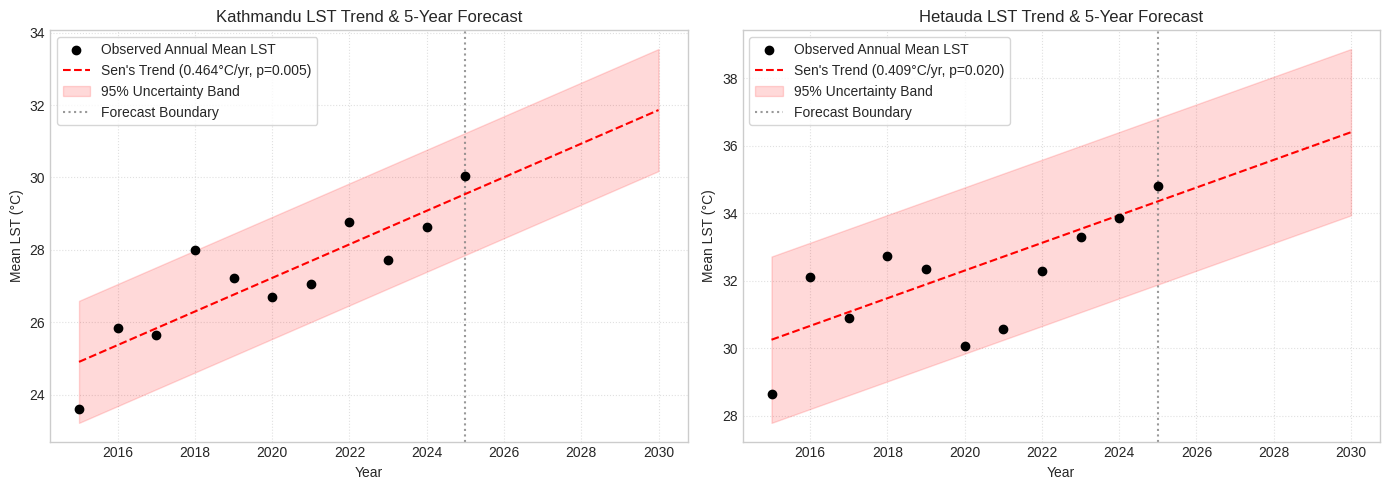

In [5]:
# ==========================================
# STEP 4 (UPDATED): PLOTTING WITH UNCERTAINTY BANDS
# ==========================================

future_years_ahead = 5  # Years to forecast into the future

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for i, (city_name, annual_df) in enumerate(cities):
    ax = axes[i]
    years = annual_df['Year'].values
    lst = annual_df['LST'].values

    # 1. Fit Sen's slope
    res = mk.original_test(lst)
    slope = res.slope
    intercept = res.intercept
    base_year = years[0]

    # Historical trend line
    historical_trend = intercept + slope * (years - base_year)

    # Calculate residual standard error to build uncertainty bounds
    residuals = lst - historical_trend
    std_err = np.std(
        residuals, ddof=1
    )  # Sample standard deviation of residuals

    # 2. Future Projections
    last_year = years[-1]
    future_years = np.arange(
        last_year + 1, last_year + 1 + future_years_ahead
    )
    future_trend = intercept + slope * (future_years - base_year)

    # 95% Confidence/Uncertainty interval (approx. 1.96 * std_err)
    # Expanding uncertainty slightly for future years is a nice touch,
    # but a constant residual band is standard and robust for small samples.
    margin = 1.96 * std_err
    historical_upper = historical_trend + margin
    historical_lower = historical_trend - margin
    future_upper = future_trend + margin
    future_lower = future_trend - margin

    # Combine historical and future arrays for seamless shading
    all_years = np.concatenate([years, future_years])
    all_trend = np.concatenate([historical_trend, future_trend])
    all_upper = np.concatenate([historical_upper, future_upper])
    all_lower = np.concatenate([historical_lower, future_lower])

    # 3. Plotting Elements
    # Scatter of actual observations
    ax.scatter(
        years, lst, color='black', label='Observed Annual Mean LST', zorder=4
    )

    # Trend line (Historical + Future)
    ax.plot(
        all_years,
        all_trend,
        color='red',
        linestyle='--',
        label=f"Sen's Trend ({slope:.3f}°C/yr, p={res.p:.3f})",
        zorder=3,
    )

    # Uncertainty Band (Shaded Area)
    ax.fill_between(
        all_years,
        all_lower,
        all_upper,
        color='red',
        alpha=0.15,
        label='95% Uncertainty Band',
        zorder=1,
    )

    # Vertical boundary line separating past from future
    ax.axvline(
        x=last_year,
        color='gray',
        linestyle=':',
        alpha=0.8,
        label='Forecast Boundary',
    )

    ax.set_title(f'{city_name} LST Trend & 5-Year Forecast')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean LST (°C)')
    ax.legend(loc='upper left', frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


--- Kathmandu Future LST Projections ---
 Year  Predicted_LST (°C)
 2026           30.006351
 2027           30.470098
 2028           30.933845
 2029           31.397593
 2030           31.861340

--- Hetauda Future LST Projections ---
 Year  Predicted_LST (°C)
 2026           34.759270
 2027           35.168629
 2028           35.577989
 2029           35.987348
 2030           36.396708


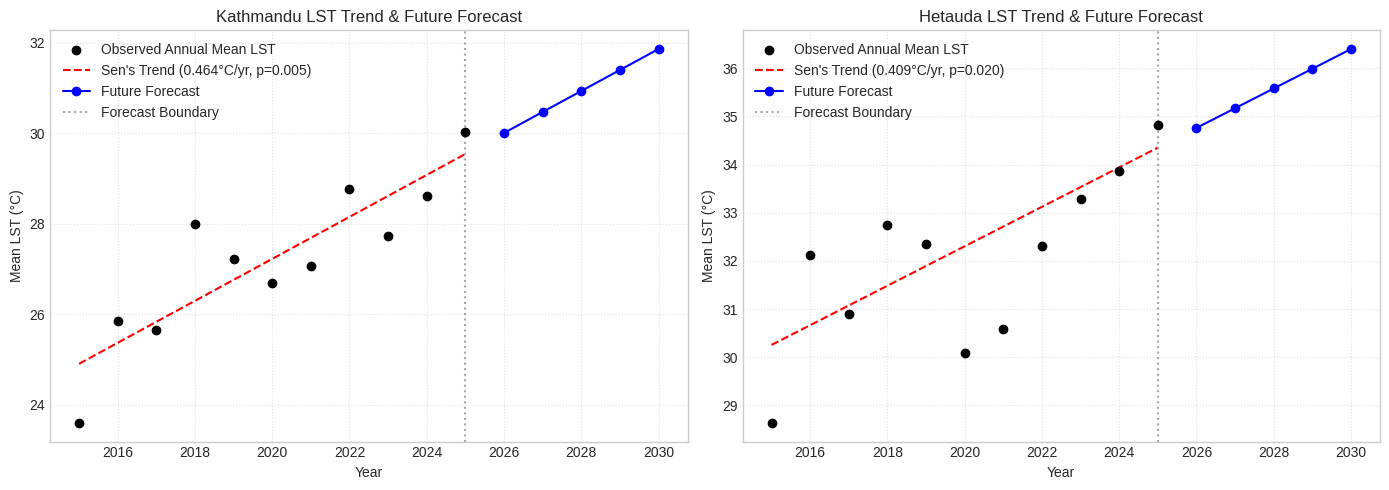

In [6]:
# ==========================================
# STEP 5: FUTURE EXTRAPOLATION (2026 and Beyond)
# ==========================================

future_years_ahead = 5  # Number of years into the future you want to forecast

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for i, (city_name, annual_df) in enumerate(cities):
    ax = axes[i]
    years = annual_df['Year'].values
    lst = annual_df['LST'].values

    # 1. Fit Sen's slope on the ENTIRE historical dataset
    res = mk.original_test(lst)
    slope = res.slope
    intercept = res.intercept
    base_year = years[0]

    # Historical trend line values
    historical_trend = intercept + slope * (years - base_year)

    # 2. Generate Future Years
    last_year = years[-1]
    future_years = np.arange(
        last_year + 1, last_year + 1 + future_years_ahead
    )
    future_trend = intercept + slope * (future_years - base_year)

    # 3. Print Future Forecast Table
    print(f'\n--- {city_name} Future LST Projections ---')
    forecast_df = pd.DataFrame(
        {'Year': future_years, 'Predicted_LST (°C)': future_trend}
    )
    print(forecast_df.to_string(index=False))

    # 4. Plotting
    ax.scatter(
        years, lst, color='black', label='Observed Annual Mean LST', zorder=3
    )
    ax.plot(
        years,
        historical_trend,
        color='red',
        linestyle='--',
        label=f"Sen's Trend ({slope:.3f}°C/yr, p={res.p:.3f})",
    )

    # Plot Future Extension
    ax.plot(
        future_years,
        future_trend,
        color='blue',
        linestyle='-',
        marker='o',
        label='Future Forecast',
    )
    ax.axvline(
        x=last_year,
        color='gray',
        linestyle=':',
        alpha=0.7,
        label='Forecast Boundary',
    )

    ax.set_title(f'{city_name} LST Trend & Future Forecast')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean LST (°C)')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()